In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [4]:
data = pd.read_csv("data.csv")
data.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [5]:
data.shape

(381109, 12)

In [6]:
data.columns

Index(['id', 'Gender', 'Age', 'Driving_License', 'Region_Code',
       'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Response'],
      dtype='object')

In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data.isna().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [10]:
data.columns = data.columns.str.lower()

In [11]:
data.describe()

,id,age,driving_license,region_code,previously_insured,annual_premium,policy_sales_channel,vintage,response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


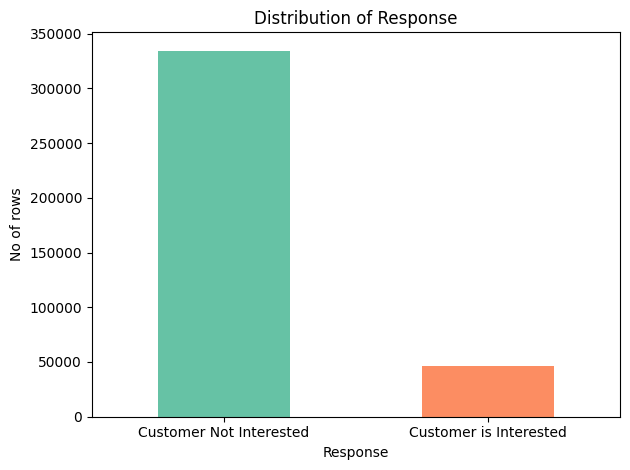

In [12]:
data["response"].value_counts().plot(kind="bar",color=plt.get_cmap("Set2").colors)
plt.xticks(ticks=[0,1],labels=["Customer Not Interested","Customer is Interested"],rotation=0)
plt.title("Distribution of Response")
plt.ylabel("No of rows")
plt.xlabel("Response")
plt.tight_layout()
plt.show()

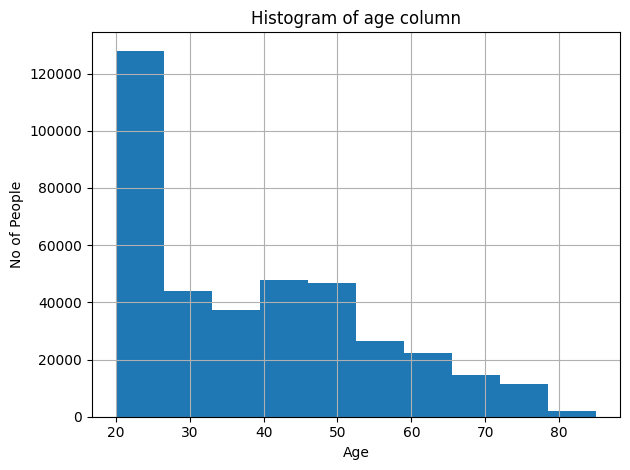

In [13]:
data["age"].hist(bins=10)
plt.title("Histogram of age column")
plt.xlabel("Age")
plt.ylabel("No of People")
plt.tight_layout()
plt.show()

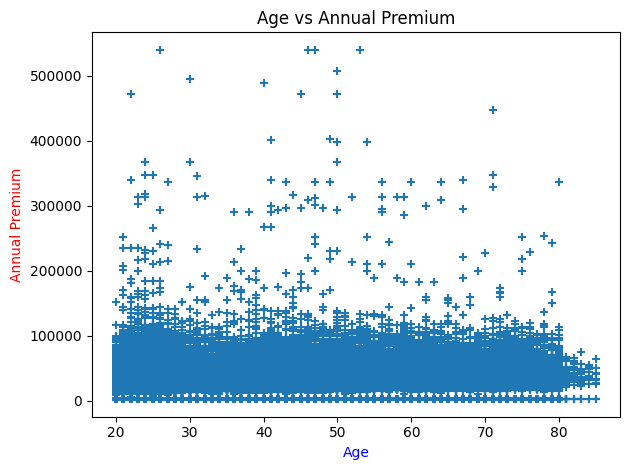

In [14]:
plt.scatter(data=data,x="age",y="annual_premium",marker="+")
plt.title("Age vs Annual Premium")
plt.xlabel("Age",color="blue")
plt.ylabel("Annual Premium",color="red")
plt.tight_layout()
plt.show()

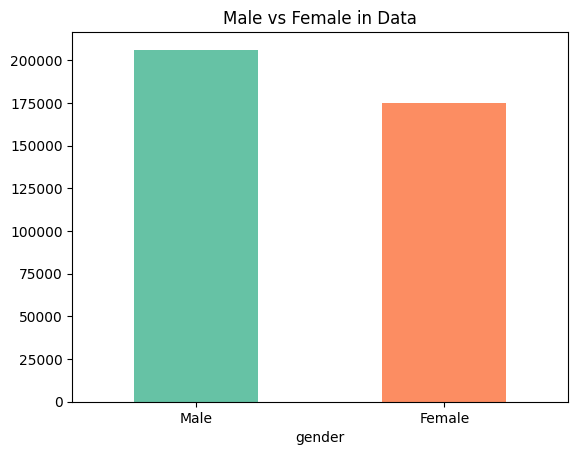

In [15]:
data["gender"].value_counts().plot(kind="bar",color=plt.get_cmap("Set2").colors)
plt.xticks(rotation=0)
plt.title("Male vs Female in Data")
plt.show()

<Axes: xlabel='gender', ylabel='count'>

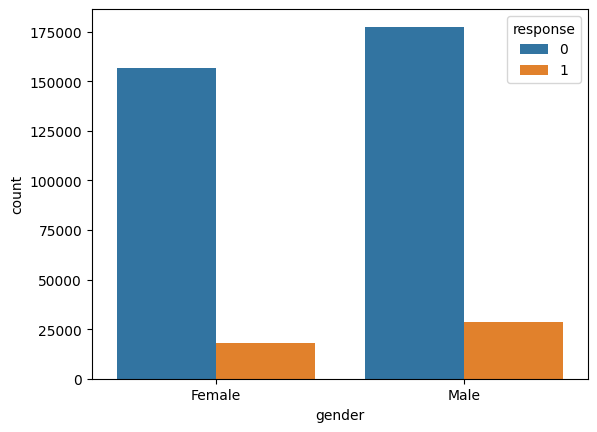

In [16]:
df = data.groupby(["gender","response"])["id"].count().to_frame().rename(columns={"id":"count"}).reset_index()

sns.barplot(data=df,x="gender",y="count",hue="response")

In [17]:
data["gender"] = data["gender"].map({"Male":0,"Female":1})

In [18]:
data.head()

,id,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,response
0,1,0,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,0,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,0,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,0,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,1,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [19]:
# creating dummy cols for categorical features

data = pd.get_dummies(data,drop_first=True)
data.head()

,id,gender,age,driving_license,region_code,previously_insured,annual_premium,policy_sales_channel,vintage,response,vehicle_age_< 1 Year,vehicle_age_> 2 Years,vehicle_damage_Yes
0,1,0,44,1,28.0,0,40454.0,26.0,217,1,False,True,True
1,2,0,76,1,3.0,0,33536.0,26.0,183,0,False,False,False
2,3,0,47,1,28.0,0,38294.0,26.0,27,1,False,True,True
3,4,0,21,1,11.0,1,28619.0,152.0,203,0,True,False,False
4,5,1,29,1,41.0,1,27496.0,152.0,39,0,True,False,False


In [20]:
data = data.rename(columns={"vehicle_age_< 1 Year":"vehicle_age_lt_1_year",
                     "vehicle_age_> 2 Years":"vehicle_age_gt_2_year",
                     "vehicle_damage_Yes":"vehicle_damage"})

In [21]:
data.head()

,id,gender,age,driving_license,region_code,previously_insured,annual_premium,policy_sales_channel,vintage,response,vehicle_age_lt_1_year,vehicle_age_gt_2_year,vehicle_damage
0,1,0,44,1,28.0,0,40454.0,26.0,217,1,False,True,True
1,2,0,76,1,3.0,0,33536.0,26.0,183,0,False,False,False
2,3,0,47,1,28.0,0,38294.0,26.0,27,1,False,True,True
3,4,0,21,1,11.0,1,28619.0,152.0,203,0,True,False,False
4,5,1,29,1,41.0,1,27496.0,152.0,39,0,True,False,False


In [22]:
data["vehicle_age_lt_1_year"] = data["vehicle_age_lt_1_year"].astype("int")
data["vehicle_age_gt_2_year"] = data["vehicle_age_gt_2_year"].astype("int")
data["vehicle_damage"] =  data["vehicle_damage"].astype("int").astype("int")

In [23]:
for col in data.columns:
    print(f"{col} ----> {data[col].dtype}")

id ----> int64
gender ----> int64
age ----> int64
driving_license ----> int64
region_code ----> float64
previously_insured ----> int64
annual_premium ----> float64
policy_sales_channel ----> float64
vintage ----> int64
response ----> int64
vehicle_age_lt_1_year ----> int64
vehicle_age_gt_2_year ----> int64
vehicle_damage ----> int64


In [24]:
num_col = ["age","annual_premium","policy_sales_channel","vintage"]
cat_col = ["gender","region_code","driving_code","previously_insured","vehicle_damage","vehicle_age_lt_1_year","vehicle_age_gt_2_year","vehicle_damage"]

In [25]:
data.head()

,id,gender,age,driving_license,region_code,previously_insured,annual_premium,policy_sales_channel,vintage,response,vehicle_age_lt_1_year,vehicle_age_gt_2_year,vehicle_damage
0,1,0,44,1,28.0,0,40454.0,26.0,217,1,0,1,1
1,2,0,76,1,3.0,0,33536.0,26.0,183,0,0,0,0
2,3,0,47,1,28.0,0,38294.0,26.0,27,1,0,1,1
3,4,0,21,1,11.0,1,28619.0,152.0,203,0,1,0,0
4,5,1,29,1,41.0,1,27496.0,152.0,39,0,1,0,0


In [26]:
data.shape

(381109, 13)

In [27]:
x = data.drop(["response"],axis=1)
y = data["response"]
x.shape,y.shape

((381109, 12), (381109,))

In [28]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
x_resampled,y_resampled = ros.fit_resample(x,y)

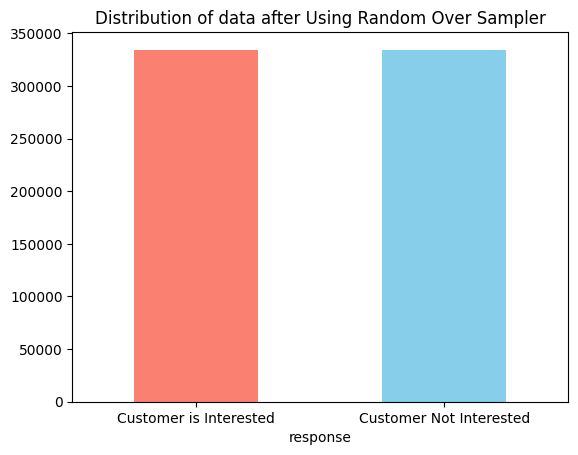

In [41]:
y_resampled.value_counts().plot(kind="bar",color=["salmon", "skyblue"])
plt.xticks(ticks=[1,0],labels=["Customer Not Interested","Customer is Interested"],rotation=0)
plt.title("Distribution of data after Using Random Over Sampler")
plt.show()

In [38]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_resampled[num_col] = sc.fit_transform(x_resampled[num_col])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
from sklearn.ensemble import RandomForestClassifier


In [43]:
x_train,x_test,y_train,y_test = train_test_split(x_resampled,y_resampled,test_size=0.2,random_state=42)

In [44]:
clf = RandomForestClassifier(n_estimators=150,random_state=42)
clf.fit(x_train,y_train)
y_pred = clf.predict(x_test)
print("Accuracy",accuracy_score(y_test,y_pred))

Accuracy 0.9578797846889953


In [ ]:
from sklearn.metrics import classification_report
print (classification_report(y_test, y_pred))

# HyperParameter Tunning

In [45]:
from sklearn.model_selection import RandomizedSearchCV
param = {
    "criterion":["gini","entropy"],
    "n_estimators":[100,200,300],
    "bootstrap":[True,False],
    'max_depth': [2,3,4,5,6,7,10],
    'min_samples_leaf': [4, 6, 8],
    'min_samples_split': [5, 7,10]
}
clf = RandomForestClassifier(random_state=42)
model = RandomizedSearchCV(estimator=clf,cv=3,verbose=1,n_jobs=-1,param_distributions=param,random_state=42,scoring="accuracy",n_iter=10)
model.fit(x_train,y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [2, 3, 4, 5, 6, 7, 10],
                                        'min_samples_leaf': [4, 6, 8],
                                        'min_samples_split': [5, 7, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='accuracy', verbose=1)

In [46]:
print(model.best_params_)
print(model.best_estimator_)
print(model.best_score_)

{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 6, 'criterion': 'gini', 'bootstrap': True}
RandomForestClassifier(max_depth=6, min_samples_leaf=4, min_samples_split=5,
                       n_estimators=200, random_state=42)
0.7944089952489356


In [47]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model.best_estimator_, x_train, y_train, cv=5)
print("Cross-validation accuracy:", scores.mean())

Cross-validation accuracy: 0.794317412339193


In [48]:
from sklearn.model_selection import cross_val_score

clf = RandomForestClassifier(n_estimators=150,random_state=42)
scores = cross_val_score(clf, x_train, y_train, cv=5)
print("Cross-validation accuracy:", scores.mean())

Cross-validation accuracy: 0.9377894637430764


In [53]:
import os
import pickle

# Create the directory if it doesn't exist
os.makedirs("../model", exist_ok=True)

# Save the model
with open("../model/model.pkl", "wb") as f:
    pickle.dump(clf, f)


# SK-Learn Pipeline

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline,FunctionTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [33]:
num_col = ["age","annual_premium","policy_sales_channel","vintage"]
cat_col = ["gender","region_code","driving_code","previously_insured","vehicle_damage","vehicle_age_lt_1_year","vehicle_age_gt_2_year","vehicle_damage"]

In [41]:
data = pd.read_csv("data.csv")
data.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [ ]:
# from imblearn.over_sampling import RandomOverSampler

# ros = RandomOverSampler(random_state=42)
# x_resampled,y_resampled = ros.fit_resample(x,y)

In [42]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler

In [ ]:
num_col = ["Age","Annual_Premium","Policy_Sales_Channel","Vintage"]
cat_col = ["Gender","Region_Code","Driving_Code","Previously_Insured","Vehicle_Damage","Vehicle_Age"]

def preprocessing_function(data):
    data = data.copy()  
    data["Gender"] = data["Gender"].map({"Male": 0, "Female": 1})
    data["Vehicle_Damage"] = data["Vehicle_Damage"].map({"No":0,"Yes":1})
    return data

# validate = True  mean it expect a numpy array
function = FunctionTransformer(preprocessing_function,validate=False)

preprocess = ColumnTransformer(
    transformers=[
        ("numeric",StandardScaler(),num_col),
        ("vehicle_age",OneHotEncoder(handle_unknown="ignore"),["Vehicle_Age"])        
    ]
)
pipe = Pipeline(
    steps=[
        ("custom_function",function),
        ("preprocess",preprocess),
        ('classifier', RandomForestClassifier(n_estimators=150, random_state=42))
    ]
)

In [54]:
x = data.drop(["Response"],axis=1)
y = data["Response"]

In [55]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [56]:
pipe.fit(x_train,y_train)
y_pred = pipe.predict(x_test)
print("Accuracy Using Pipeline",accuracy_score(y_test,y_pred))

Accuracy Using Pipeline 0.8555928734486107


In [ ]:
import os
import pickle
# Create the directory if it doesn't exist
os.makedirs("../model", exist_ok=True)

# Save the model
with open("../model/pipe.pkl", "wb") as f:
    pickle.dump(pipe, f)

In [ ]:
import pandas as pd

user_input = pd.DataFrame([{
    "Gender": "Male",
    "Age": 35,
    "Driving_License": 1,
    "Region_Code": 28.0,
    "Previously_Insured": 0,
    "Vehicle_Age": "< 1 Year",
    "Vehicle_Damage": "Yes",
    "Annual_Premium": 30000.0,
    "Policy_Sales_Channel": 152.0,
    "Vintage": 150
}])
prediction = pipe.predict(user_input)
print("Prediction:", prediction)

Prediction: [0]
